In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/student.csv')

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
df.shape

(6607, 20)

In [7]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [8]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [11]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

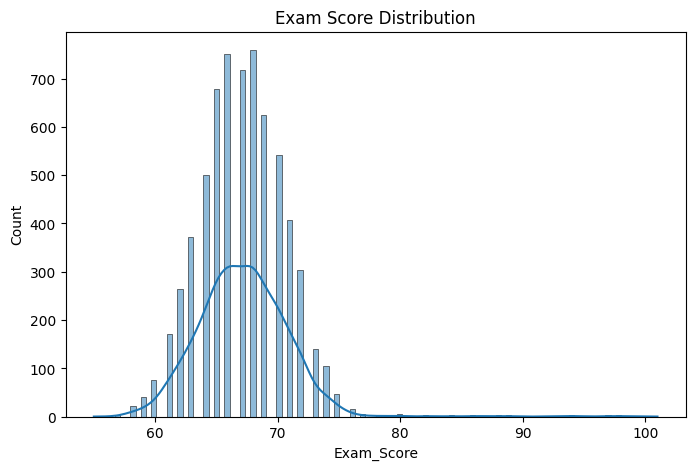

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Exam Score Distribution")
plt.show()

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols

C:\Users\prabh\AppData\Local\Temp\ipykernel_3360\1115346021.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [14]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [15]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print(X.shape)
print(y.shape)

(6607, 27)
(6607,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

for k in range(1, 16):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("k =", k, "R2 =", r2_score(y_test, y_pred))

k = 1 R2 = -0.12080519308085758
k = 2 R2 = 0.2752948755729925
k = 3 R2 = 0.3632026517369731
k = 4 R2 = 0.39638788555046955
k = 5 R2 = 0.4278948786494622
k = 6 R2 = 0.4311005089848208
k = 7 R2 = 0.43513277511214654
k = 8 R2 = 0.44465785710122074
k = 9 R2 = 0.4543052694728589
k = 10 R2 = 0.4586811668239985
k = 11 R2 = 0.46262583567334825
k = 12 R2 = 0.4672360946717884
k = 13 R2 = 0.4676503385520294
k = 14 R2 = 0.4728806180393015
k = 15 R2 = 0.46983065023795867


In [19]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=14)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.8085152366544195
MSE: 7.45087066596684
RMSE: 2.729628301796206
R2 Score: 0.4728806180393015


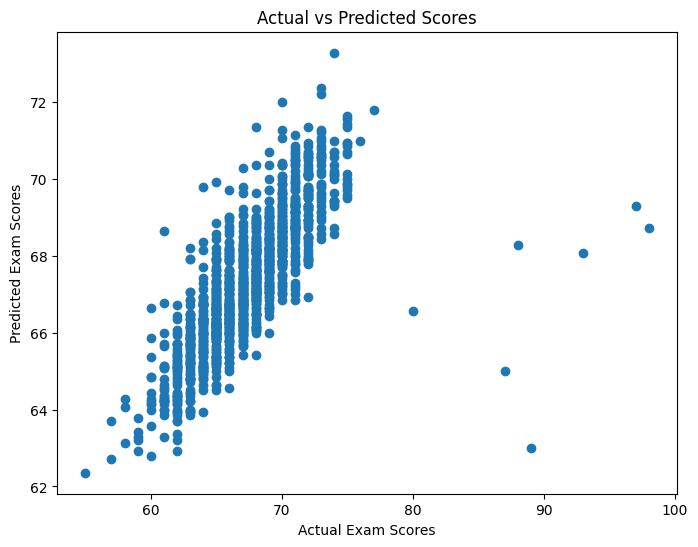

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

In [22]:
import joblib

joblib.dump(model, "../models/knn_regressor.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']